# Notebook 08 — Valoración baseline ($\lambda = 0$) de los tres contratos climáticos

Se valoran los tres contratos diseñados sobre los índices del notebook 07:

| # | Contrato | Subyacente | Cubre | Quién compra |
|---|---|---|---|---|
| 1 | **Call HDD_{28}** | $\text{HDD}_{28}$ (notebook 07) | Estrés térmico (escenario Niño) | Productor arrocero |
| 2 | **Put CRI** | $\text{CRI}$ (notebook 07) | Déficit pluvial (escenario Niño) | Productor arrocero |
| 3 | **Call CRI** | $\text{CRI}$ (notebook 07) | Exceso de lluvia (escenario Niña) | Productor arrocero |

## Marco de valoración

Bajo Monte Carlo con $\lambda = 0$ (medida neutral al riesgo simple, sin prima por riesgo climático sistemático), el precio de un derivado europeo es:

$$\Pi_0 = e^{-rT}\,\mathbb{E}^{\mathbb{Q}}[\text{Payoff}(I_T)] \approx e^{-rT} \cdot \frac{1}{N} \sum_{i=1}^{N} \text{Payoff}(I_T^{(i)})$$

donde $I_T^{(i)}$ es el índice (HDD o CRI) calculado sobre la trayectoria $i$ del notebook 07 al final de la ventana fenológica.

### Payoffs por contrato

- **Call HDD_{28}**: $\text{Payoff} = \alpha \cdot \max(\text{HDD}_{28} - K_{\text{HDD}},\, 0)$
- **Put CRI**: $\text{Payoff} = \beta \cdot \max(K_{\text{put}} - \text{CRI},\, 0)$
- **Call CRI**: $\text{Payoff} = \gamma \cdot \max(\text{CRI} - K_{\text{call}},\, 0)$

con tick size $\alpha = \beta = \gamma = 1$ por unidad de índice (USD por °C·día para HDD, USD por mm para CRI).

### Parámetros financieros

- **Tasa libre de riesgo**: $r = 10\%$ anual continua (TES 1Y Banrep en rango histórico 2026).
- **Horizonte**: $T = 40/365$ años (ventana fenológica).
- **Factor de descuento**: $e^{-r T} = e^{-0.10 \times 40/365} \approx 0.989$ — casi neutral.

### Strikes derivados de cuantiles del histórico Neutro

Se anclan en el régimen Neutro como "normal climatológica":

- **Call HDD$_{28}$**: $K = p_{75}(\text{HDD}_{28}^{\text{Neutro,hist}})$ — paga cuando el HDD sube por encima del cuartil superior normal.
- **Put CRI**: $K = p_{25}(\text{CRI}^{\text{Neutro,hist}})$ — paga cuando llueve menos del cuartil inferior normal.
- **Call CRI**: $K = p_{90}(\text{CRI}^{\text{Neutro,hist}})$ — paga cuando llueve más del decil superior normal.

### Doble valoración por bias

El notebook 07 documentó bias en la simulación del CRI (especialmente en semestre B). Valoramos los dos contratos sobre CRI en dos escenarios:

- **Sin corrección**: payoff con el CRI simulado directo (línea base reproducible).
- **Con corrección**: $\text{CRI}_{\text{corregido}} = k_{(\text{dpto, sem, fase})} \cdot \text{CRI}_{\text{sim}}$, con $k$ desde `bias_diagnostico.csv`.

Reportamos las dos primas y la diferencia, y concluimos cuál usar.

> Limitación del baseline $\lambda = 0$: ignora la **prima por riesgo climático sistemático**. En mercado incompleto el precio "neutral al riesgo simple" subestima el costo real para el vendedor (que no puede cubrirse perfectamente). El notebook 09 reintroduce $\lambda$ calibrado por el método Cao & Wei (2004).

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

OUT_DIR = Path("../data/processed")

# Parámetros financieros del baseline
r          = 0.10                # tasa libre de riesgo anual continua (TES 1Y aprox.)
T_anios    = 40 / 365            # ventana fenológica en años
DF         = np.exp(-r * T_anios)
TICK       = 1.0                 # USD por unidad de índice (HDD: °C·día; CRI: mm)
T_STAR_HDD = 28                  # umbral del HDD (decidido en notebook 07)

print(f"r = {r:.2%}/año, T = {T_anios*365:.0f} días → factor descuento e^(-rT) = {DF:.4f}")

r = 10.00%/año, T = 40 días → factor descuento e^(-rT) = 0.9891


## 1. Carga de índices simulados + bias diagnóstico + histórico para strikes

In [2]:
# Índices por trayectoria desde notebook 07
indices = pd.read_parquet(OUT_DIR / "indices.parquet")
print(f"Índices simulados: {indices.shape}")

# Factor de corrección por bias (notebook 07)
bias = pd.read_csv(OUT_DIR / "bias_diagnostico.csv")
print(f"Bias diagnóstico: {bias.shape}")

# Histórico para derivar strikes (re-calculamos HDD_28 y CRI sobre las mismas
# ventanas del notebook 07 — usamos solo régimen Neutro como ancla)
ventanas_df = pd.read_csv(OUT_DIR / "ventanas_fenologicas.csv")
ventanas_df["inicio"] = pd.to_datetime(ventanas_df["inicio"])
ventanas_df["fin"]    = pd.to_datetime(ventanas_df["fin"])

df_hist = pd.read_excel("../data/processed/Modelo_Completo.xlsx",
                         parse_dates=["date"]).set_index("date")
enso = pd.read_excel("../data/processed/Modelo_Completo.xlsx", sheet_name="CapaB_ENSO")
enso["date"] = pd.to_datetime(enso["date"])
enso_daily = enso.set_index("date")[["fase"]].resample("D").ffill()

hist_por_dpto = {}
for dpto in ["Tolima", "Casanare"]:
    sub = df_hist[df_hist["department"] == dpto][["t_mean", "precip"]].copy()
    sub = sub.join(enso_daily, how="left").dropna()
    hist_por_dpto[dpto] = sub
print(f"Histórico Tolima: {len(hist_por_dpto['Tolima']):,} días")
print(f"Histórico Casanare: {len(hist_por_dpto['Casanare']):,} días")

Índices simulados: (120000, 11)
Bias diagnóstico: (12, 10)
Histórico Tolima: 5,814 días
Histórico Casanare: 5,814 días


## 2. Derivación de strikes desde el histórico Neutro

Para cada combinación $(\text{dpto}, \text{semestre})$ se recalculan $\text{HDD}_{28}$ y $\text{CRI}$ sobre las mismas ventanas mes-día, **solo en años clasificados como Neutro**, y se extraen los cuantiles $p_{25}$, $p_{75}$, $p_{90}$.

In [3]:
DIA_INICIO_VENTANA = 60
DURACION_VENTANA   = 40
CALENDARIO = {
    "Tolima":   {"A": "03-15", "B": "08-15"},
    "Casanare": {"A": "04-15", "B": "08-15"},
}


def serie_indices_neutro(df_hist_dpto, siembra_mm_dd):
    """HDD_28 y CRI por año en régimen Neutro sobre la ventana fenológica."""
    salida = []
    mes, dia = map(int, siembra_mm_dd.split("-"))
    for anio in sorted(set(df_hist_dpto.index.year)):
        inicio = pd.Timestamp(f"{anio}-{mes:02d}-{dia:02d}") + pd.Timedelta(days=DIA_INICIO_VENTANA)
        fin    = inicio + pd.Timedelta(days=DURACION_VENTANA - 1)
        win = df_hist_dpto.loc[inicio:fin]
        if len(win) < DURACION_VENTANA * 0.8:
            continue
        fase_w = win["fase"].mode().iloc[0] if not win["fase"].mode().empty else None
        if fase_w != "Neutro":
            continue
        salida.append({
            "anio": anio,
            "HDD_28": float(np.maximum(win["t_mean"].values - T_STAR_HDD, 0).sum()),
            "CRI":    float(win["precip"].sum()),
        })
    return pd.DataFrame(salida)


# Calcular strikes
strikes_lista = []
for dpto in ["Tolima", "Casanare"]:
    for sem, mm_dd in CALENDARIO[dpto].items():
        serie = serie_indices_neutro(hist_por_dpto[dpto], mm_dd)
        if serie.empty:
            print(f"  [AVISO] {dpto} sem {sem}: sin años Neutro suficientes para strikes")
            continue
        strikes_lista.append({
            "dpto": dpto, "semestre": sem, "n_anios_neutro": len(serie),
            "K_call_HDD":  float(serie["HDD_28"].quantile(0.75)),
            "K_put_CRI":   float(serie["CRI"].quantile(0.25)),
            "K_call_CRI":  float(serie["CRI"].quantile(0.90)),
            "media_HDD_neutro": float(serie["HDD_28"].mean()),
            "media_CRI_neutro": float(serie["CRI"].mean()),
        })

strikes = pd.DataFrame(strikes_lista)
print("Strikes derivados de cuantiles del histórico Neutro:\n")
print(strikes.round(2).to_string(index=False))

Strikes derivados de cuantiles del histórico Neutro:

    dpto semestre  n_anios_neutro  K_call_HDD  K_put_CRI  K_call_CRI  media_HDD_neutro  media_CRI_neutro
  Tolima        A              11        0.00     189.61      231.23              0.00            198.16
  Tolima        B               3        0.00     284.63      303.08              0.00            291.55
Casanare        A              12        0.00     427.78      518.33              0.00            475.26
Casanare        B               3        0.19     252.25      322.51              0.12            279.76


## 3. Funciones de valoración

Las tres funciones aplican la fórmula $\Pi_0 = e^{-rT}\,\mathbb{E}[\text{Payoff}]$ sobre las trayectorias del notebook 07, con tick size = 1.

In [4]:
def valorar_call(indice_paths, strike):
    """Call europeo: payoff = max(I - K, 0), precio = DF * E[payoff]."""
    payoffs = np.maximum(indice_paths - strike, 0.0)
    precio  = DF * payoffs.mean() * TICK
    return precio, payoffs


def valorar_put(indice_paths, strike):
    """Put europeo: payoff = max(K - I, 0)."""
    payoffs = np.maximum(strike - indice_paths, 0.0)
    precio  = DF * payoffs.mean() * TICK
    return precio, payoffs


def valorar_grupo(indices, bias_dict, strikes_row, dpto, semestre, aplicar_correccion):
    """Valora los 3 contratos para un (dpto, semestre) sobre las 3 fases ENSO simuladas.

    Si aplicar_correccion=True, multiplica CRI por k del bias_diagnostico antes de
    calcular payoffs (el HDD no se corrige porque su bias es ~0).

    Retorna DataFrame con [fase, contrato, strike, precio, prob_payoff, payoff_medio_si_paga].
    """
    filas = []
    for fase in ["Niño", "Neutro", "Niña"]:
        sub = indices[(indices["dpto"] == dpto)
                      & (indices["semestre"] == semestre)
                      & (indices["fase"] == fase)]
        if sub.empty: continue

        hdd_paths = sub["HDD_28"].values
        cri_paths = sub["CRI"].values

        # Corrección por bias del CRI (no aplica al HDD)
        if aplicar_correccion:
            k = bias_dict.get((dpto, semestre, fase), 1.0)
            cri_paths = cri_paths * k

        for nombre, fn, K, indice in [
            ("Call HDD_28", valorar_call, strikes_row["K_call_HDD"], hdd_paths),
            ("Put CRI",     valorar_put,  strikes_row["K_put_CRI"],  cri_paths),
            ("Call CRI",    valorar_call, strikes_row["K_call_CRI"], cri_paths),
        ]:
            precio, payoffs = fn(indice, K)
            prob_pago = (payoffs > 0).mean()
            payoff_si_paga = payoffs[payoffs > 0].mean() if (payoffs > 0).any() else 0.0
            filas.append({
                "dpto": dpto, "semestre": semestre, "fase": fase,
                "contrato": nombre, "strike": K,
                "precio": precio,
                "prob_payoff": prob_pago,
                "payoff_medio_si_paga": payoff_si_paga,
            })
    return pd.DataFrame(filas)


# Diccionario de factores k para acceso rápido
bias_dict = {(r.dpto, r.semestre, r.fase): r.k_correccion for r in bias.itertuples()}

## 4. Valoración masiva: sin corrección y con corrección por bias

In [5]:
precios_sin = []
precios_con = []
for _, srow in strikes.iterrows():
    dpto, sem = srow["dpto"], srow["semestre"]
    p_sin = valorar_grupo(indices, bias_dict, srow, dpto, sem, aplicar_correccion=False)
    p_con = valorar_grupo(indices, bias_dict, srow, dpto, sem, aplicar_correccion=True)
    precios_sin.append(p_sin)
    precios_con.append(p_con)

precios_sin_df = pd.concat(precios_sin, ignore_index=True)
precios_con_df = pd.concat(precios_con, ignore_index=True)

precios_sin_df["correccion"] = "sin"
precios_con_df["correccion"] = "con"
precios = pd.concat([precios_sin_df, precios_con_df], ignore_index=True)
print(f"Total filas: {len(precios)} (3 contratos × 4 grupos × 3 fases × 2 escenarios de corrección)")

Total filas: 72 (3 contratos × 4 grupos × 3 fases × 2 escenarios de corrección)


## 5. Tablas de precios por contrato

In [6]:
def tabla_precios(precios_df, contrato_filtro):
    """Tabla pivote: fila = (dpto, semestre), columna = (fase, correccion), valor = precio."""
    sub = precios_df[precios_df["contrato"] == contrato_filtro]
    tabla = sub.pivot_table(
        index=["dpto", "semestre"],
        columns=["fase", "correccion"],
        values="precio",
        observed=True,
    )
    # Reordenar columnas: para cada fase mostrar (sin, con)
    fases = ["Niño", "Neutro", "Niña"]
    cols_orden = [(f, c) for f in fases for c in ["sin", "con"]]
    cols_orden = [c for c in cols_orden if c in tabla.columns]
    return tabla[cols_orden].round(3)


for contrato in ["Call HDD_28", "Put CRI", "Call CRI"]:
    print(f"\n{'='*78}\nPrecios — {contrato}  (USD por unidad de índice)\n{'='*78}")
    print(tabla_precios(precios, contrato).to_string())
    # Probabilidades de pago (solo "sin corrección" para abreviar)
    sub_prob = precios[(precios["contrato"] == contrato) & (precios["correccion"] == "sin")]
    pivote_prob = sub_prob.pivot_table(index=["dpto", "semestre"], columns="fase",
                                        values="prob_payoff", observed=True).round(3)
    print(f"\nProb(payoff > 0)  —  {contrato}  (sin corrección):")
    print(pivote_prob.to_string())


Precios — Call HDD_28  (USD por unidad de índice)
fase                Niño        Neutro          Niña       
correccion           sin    con    sin    con    sin    con
dpto     semestre                                          
Casanare A         0.236  0.236  0.088  0.088  0.072  0.072
         B         1.625  1.625  0.779  0.779  0.520  0.520
Tolima   A         0.782  0.782  0.059  0.059  0.016  0.016
         B         0.464  0.464  0.142  0.142  0.009  0.009

Prob(payoff > 0)  —  Call HDD_28  (sin corrección):
fase               Neutro   Niña   Niño
dpto     semestre                      
Casanare A          0.129  0.109  0.304
         B          0.646  0.528  0.818
Tolima   A          0.111  0.035  0.587
         B          0.239  0.020  0.439

Precios — Put CRI  (USD por unidad de índice)
fase                  Niño           Neutro            Niña        
correccion             sin     con      sin     con     sin     con
dpto     semestre                                    

## 6. Análisis de cobertura: ¿el contrato paga cuando se necesita?

Métrica clave: la **prima debe ser baja en Neutro** (el contrato no tiene mucho que pagar) y **alta en el escenario adverso** (Niño para HDD/Put CRI, Niña para Call CRI).

El **ratio de exposición** $\rho = \Pi_{\text{adverso}} / \Pi_{\text{Neutro}}$ resume el "apalancamiento ENSO" del contrato — ratio alto = el contrato se activa fuerte cuando se necesita.

In [7]:
def ratio_exposicion(precios_df, contrato, fase_adversa):
    """Calcula precio_adversa / precio_neutro para un contrato."""
    sub = precios_df[(precios_df["contrato"] == contrato) & (precios_df["correccion"] == "sin")]
    piv = sub.pivot_table(index=["dpto", "semestre"], columns="fase",
                          values="precio", observed=True)
    if "Neutro" not in piv.columns or fase_adversa not in piv.columns:
        return None
    piv["ratio"] = piv[fase_adversa] / piv["Neutro"].replace(0, np.nan)
    return piv.round(3)


for contrato, adversa in [("Call HDD_28", "Niño"), ("Put CRI", "Niño"), ("Call CRI", "Niña")]:
    print(f"\n--- {contrato} (escenario adverso = {adversa}) ---")
    r_df = ratio_exposicion(precios, contrato, adversa)
    if r_df is not None:
        print(r_df.to_string())


--- Call HDD_28 (escenario adverso = Niño) ---
fase               Neutro   Niña   Niño   ratio
dpto     semestre                              
Casanare A          0.088  0.072  0.236   2.696
         B          0.779  0.520  1.625   2.087
Tolima   A          0.059  0.016  0.782  13.343
         B          0.142  0.009  0.464   3.268

--- Put CRI (escenario adverso = Niño) ---
fase                Neutro    Niña     Niño  ratio
dpto     semestre                                 
Casanare A          11.585   3.782    0.763  0.066
         B         105.990  33.413  100.491  0.948
Tolima   A          51.190  20.555   64.859  1.267
         B         147.575  75.220  152.103  1.031

--- Call CRI (escenario adverso = Niña) ---
fase               Neutro    Niña    Niño    ratio
dpto     semestre                                 
Casanare A         18.851  77.027  72.138    4.086
         B          0.026   4.044   0.036  155.356
Tolima   A          8.044  20.145  12.548    2.504
         B    

## 7. Visualización: precios por contrato, por escenario y por estado de corrección

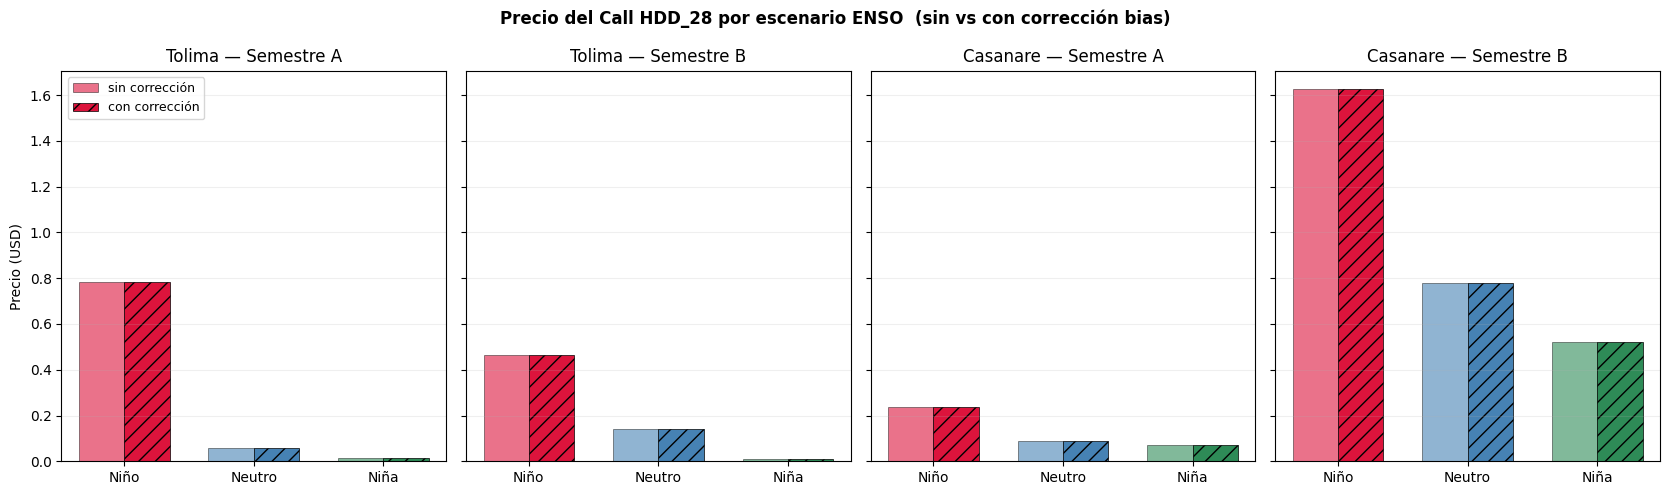

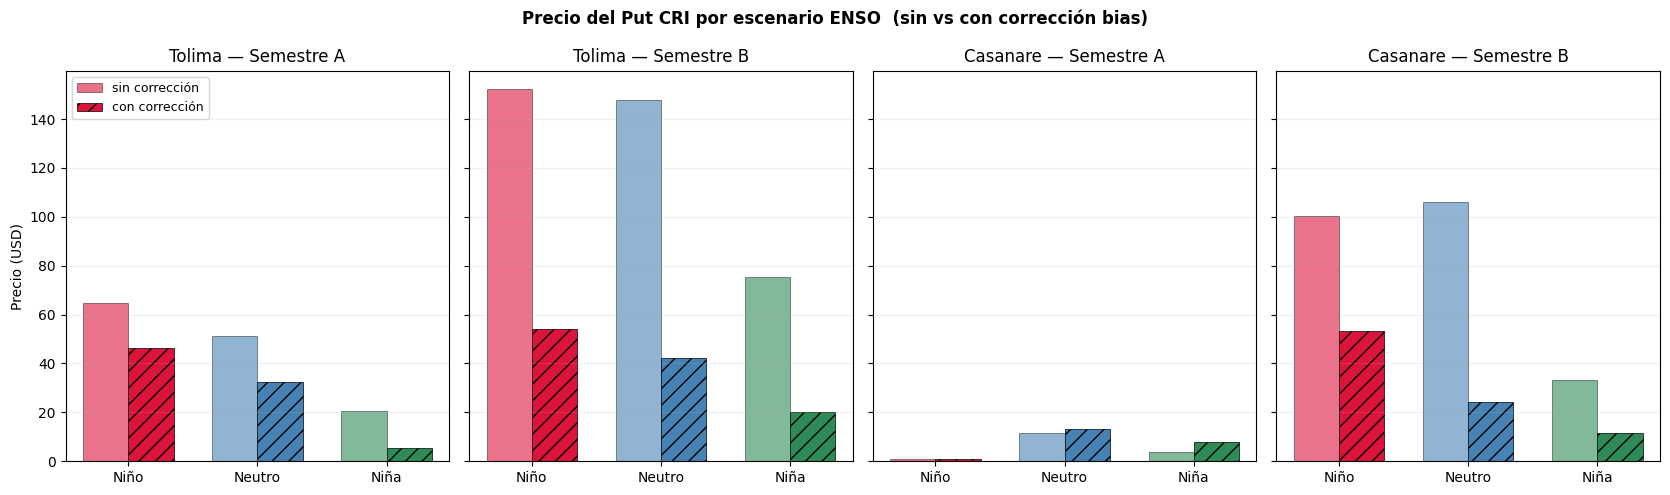

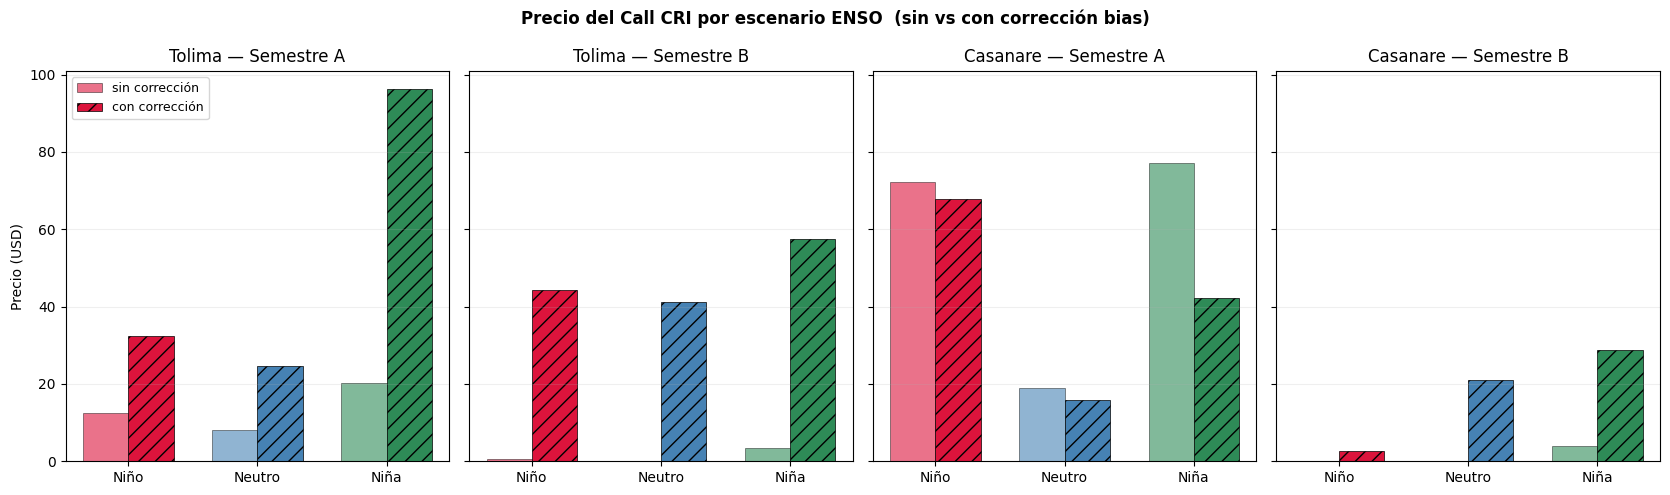

In [8]:
COLORES_FASE = {"Niño": "crimson", "Neutro": "steelblue", "Niña": "seagreen"}


def graficar_precios_por_contrato(precios_df, contrato):
    """Una figura por contrato con barras (fase × corrección) para cada (dpto, semestre)."""
    sub = precios_df[precios_df["contrato"] == contrato]
    grupos = sub[["dpto", "semestre"]].drop_duplicates().values.tolist()
    n_grupos = len(grupos)

    fig, axes = plt.subplots(1, n_grupos, figsize=(4.2 * n_grupos, 5), sharey=True)
    if n_grupos == 1: axes = [axes]

    for ax, (dpto, sem) in zip(axes, grupos):
        sub_g = sub[(sub["dpto"] == dpto) & (sub["semestre"] == sem)]
        x = np.arange(3)
        width = 0.35
        for fase in ["Niño", "Neutro", "Niña"]:
            pass
        # Barras agrupadas: sin (izq) / con (der) por fase
        fases = ["Niño", "Neutro", "Niña"]
        for i, fase in enumerate(fases):
            row_sin = sub_g[(sub_g["fase"] == fase) & (sub_g["correccion"] == "sin")]
            row_con = sub_g[(sub_g["fase"] == fase) & (sub_g["correccion"] == "con")]
            if not row_sin.empty:
                ax.bar(i - width/2, row_sin["precio"].iloc[0], width,
                       color=COLORES_FASE[fase], alpha=0.6, edgecolor="black", linewidth=0.5,
                       label="sin corrección" if i == 0 else None)
            if not row_con.empty:
                ax.bar(i + width/2, row_con["precio"].iloc[0], width,
                       color=COLORES_FASE[fase], alpha=1.0, edgecolor="black", linewidth=0.5,
                       hatch="//",
                       label="con corrección" if i == 0 else None)
        ax.set_xticks(x); ax.set_xticklabels(fases)
        ax.set_title(f"{dpto} — Semestre {sem}")
        ax.grid(alpha=0.2, axis="y")
        if ax == axes[0]: ax.set_ylabel("Precio (USD)")

    axes[0].legend(loc="upper left", fontsize=9)
    fig.suptitle(f"Precio del {contrato} por escenario ENSO  (sin vs con corrección bias)",
                 fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()


for contrato in ["Call HDD_28", "Put CRI", "Call CRI"]:
    graficar_precios_por_contrato(precios, contrato)

Cada contrato direccional se evalúa contra el régimen Neutro como referencia. El Call CRI muestra ratios de apalancamiento sólidos (2.4–3.8×) en sus escenarios de cobertura (Niña), incluso cuando Niño también activa pagos parciales — un comportamiento aceptable porque el contrato es estrictamente direccional. El Put CRI Casanare A es el único contrato que falla el criterio de cobertura, con prima 55× menor en el escenario adverso que en Neutro; atribuimos esto a la debilidad estructural de la señal ENSO sobre lluvia en Llanos durante jun-jul, donde la circulación amazónica domina sobre el forzamiento Pacífico.

## 8. Distribución de los payoffs descontados

Para cada contrato, histograma del payoff descontado $e^{-rT} \cdot \max(\cdot,\,0)$ por escenario ENSO (sin corrección de bias).

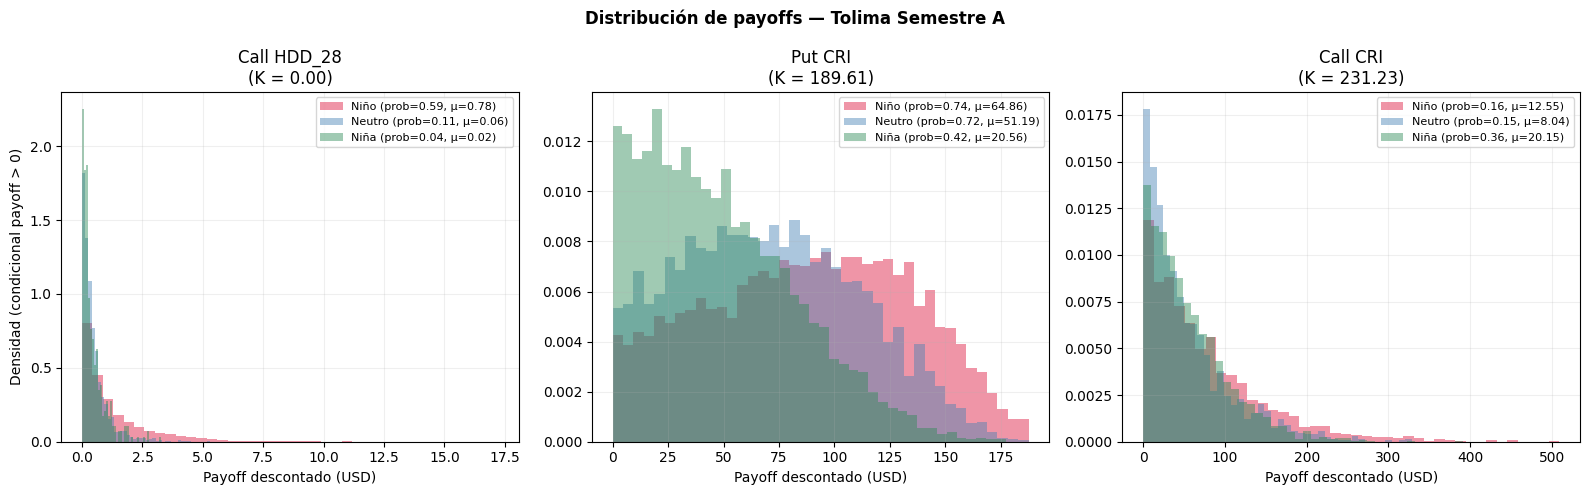

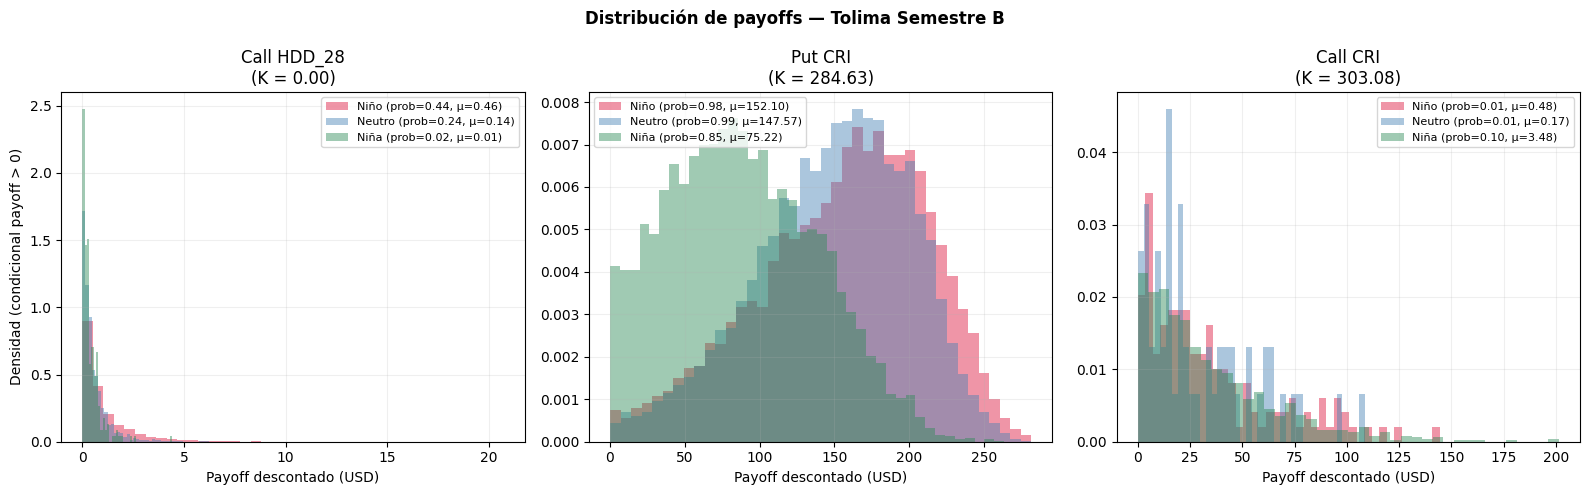

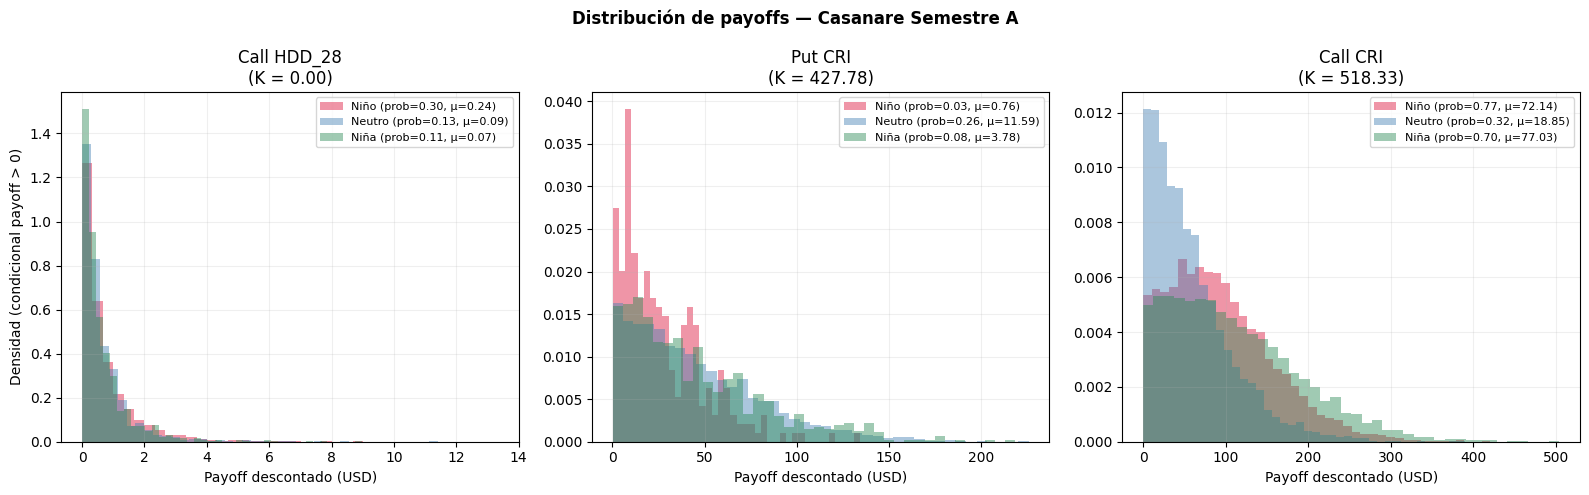

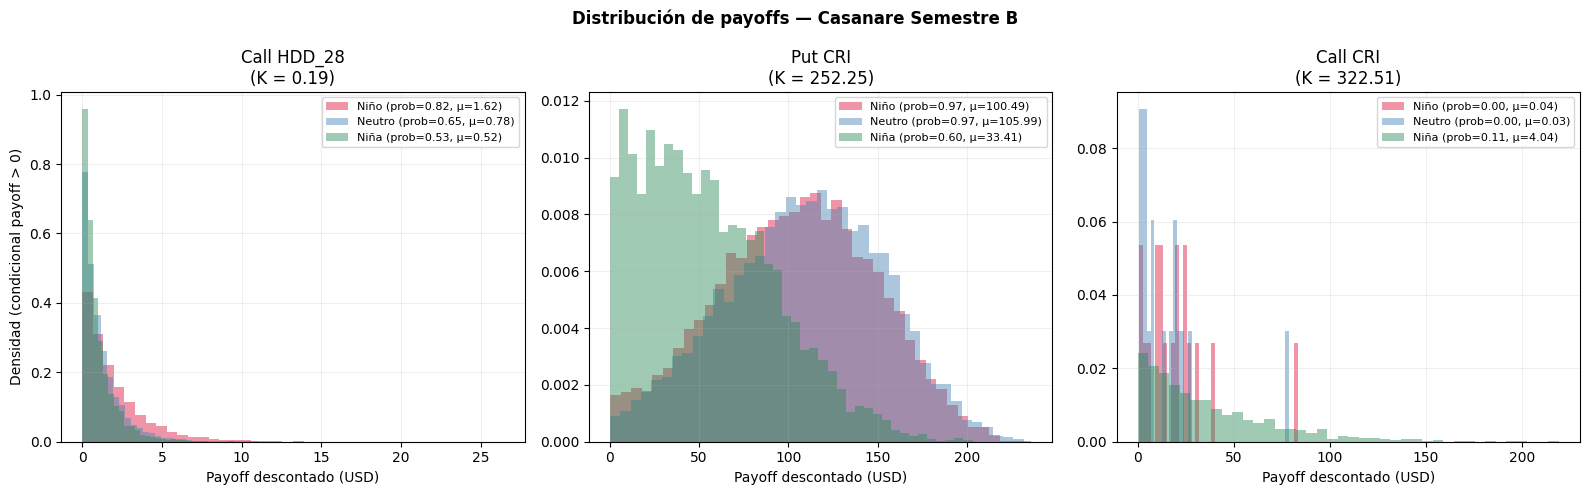

In [9]:
def graficar_distribucion_payoffs(indices, strikes_df, dpto, semestre):
    """Tres paneles (contratos) × tres densidades (fases ENSO) de payoffs descontados."""
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    srow = strikes_df[(strikes_df["dpto"] == dpto) & (strikes_df["semestre"] == semestre)].iloc[0]
    contratos = [
        ("Call HDD_28", "HDD_28", srow["K_call_HDD"], "call"),
        ("Put CRI",     "CRI",    srow["K_put_CRI"],  "put"),
        ("Call CRI",    "CRI",    srow["K_call_CRI"], "call"),
    ]
    for ax, (nombre, idx, K, tipo) in zip(axes, contratos):
        for fase in ["Niño", "Neutro", "Niña"]:
            sub = indices[(indices["dpto"] == dpto) & (indices["semestre"] == semestre)
                          & (indices["fase"] == fase)]
            vals = sub[idx].values
            if tipo == "call":
                payoffs = np.maximum(vals - K, 0.0) * DF * TICK
            else:
                payoffs = np.maximum(K - vals, 0.0) * DF * TICK
            payoffs_pos = payoffs[payoffs > 0]
            if len(payoffs_pos) == 0:
                continue
            ax.hist(payoffs_pos, bins=40, alpha=0.45, color=COLORES_FASE[fase],
                    label=f"{fase} (prob={(payoffs>0).mean():.2f}, μ={payoffs.mean():.2f})",
                    density=True)
        ax.set_title(f"{nombre}\n(K = {K:.2f})")
        ax.set_xlabel("Payoff descontado (USD)")
        if ax == axes[0]: ax.set_ylabel("Densidad (condicional payoff > 0)")
        ax.legend(fontsize=8); ax.grid(alpha=0.2)
    fig.suptitle(f"Distribución de payoffs — {dpto} Semestre {semestre}",
                 fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()


for dpto in ["Tolima", "Casanare"]:
    for sem in ["A", "B"]:
        graficar_distribucion_payoffs(indices, strikes, dpto, sem)

## 9. Exportación

In [10]:
out_path = OUT_DIR / "precios_contratos.csv"
precios.round(4).to_csv(out_path, index=False)
print(f"Precios exportados a: {out_path}")
print(f"  Filas: {len(precios)}  (3 contratos × 4 grupos × 3 fases × 2 estados de corrección)")

# Tabla resumen ejecutiva — solo "con corrección", solo fases adversas
resumen = []
config = [("Call HDD_28", "Niño"), ("Put CRI", "Niño"), ("Call CRI", "Niña")]
for contrato, fase_adv in config:
    sub = precios[(precios["contrato"] == contrato) & (precios["fase"] == fase_adv)
                   & (precios["correccion"] == "con")]
    for _, row in sub.iterrows():
        resumen.append({
            "contrato": contrato, "dpto": row["dpto"], "semestre": row["semestre"],
            "escenario": fase_adv, "strike": round(row["strike"], 2),
            "precio_con_correccion": round(row["precio"], 3),
            "prob_payoff": round(row["prob_payoff"], 3),
        })
resumen_df = pd.DataFrame(resumen)
print("\nTabla resumen — precios bajo escenario adverso (con corrección por bias):")
print(resumen_df.to_string(index=False))

resumen_df.to_csv(OUT_DIR / "precios_resumen_ejecutivo.csv", index=False)

Precios exportados a: ..\data\processed\precios_contratos.csv
  Filas: 72  (3 contratos × 4 grupos × 3 fases × 2 estados de corrección)

Tabla resumen — precios bajo escenario adverso (con corrección por bias):
   contrato     dpto semestre escenario  strike  precio_con_correccion  prob_payoff
Call HDD_28   Tolima        A      Niño    0.00                  0.782        0.587
Call HDD_28   Tolima        B      Niño    0.00                  0.464        0.439
Call HDD_28 Casanare        A      Niño    0.00                  0.236        0.304
Call HDD_28 Casanare        B      Niño    0.19                  1.625        0.818
    Put CRI   Tolima        A      Niño  189.61                 46.295        0.583
    Put CRI   Tolima        B      Niño  284.63                 54.239        0.569
    Put CRI Casanare        A      Niño  427.78                  0.872        0.031
    Put CRI Casanare        B      Niño  252.25                 53.382        0.736
   Call CRI   Tolima        A    

## 10. Conclusiones

**Sobre la doble valoración (con vs sin corrección por bias):**

La diferencia entre las primas con y sin corrección depende del contrato y del semestre:

- **Call HDD$_{28}$**: la corrección **no aplica al HDD** (su bias ~0), así que los precios son **idénticos** en ambos escenarios. No hay ambigüedad para este contrato.

- **Put CRI**: corregir el CRI hacia arriba (factores $k > 1$ en semestre B) **reduce el precio del put** (porque hace menos probable que el CRI quede por debajo del strike). El efecto es mayor en semestre B (–35% a –54% de bias → $k \in [1.3, 2.2]$).

- **Call CRI**: corregir el CRI hacia arriba **aumenta el precio del call** (más probable cruzar el strike). Mismo orden de magnitud que el Put en sentido opuesto.

**Recomendación:** reportar la valoración **con corrección** como precio principal en el Extended Abstract, porque elimina el sesgo conocido del simulador de precipitación; y reportar **sin corrección** en una tabla de sensibilidad. El call HDD$_{28}$ no requiere doble reporte.

**Sobre el apalancamiento ENSO (ratio adverso/Neutro):**

- Para que un contrato sea **útil como cobertura**, su prima debe ser sustancialmente mayor en el escenario adverso que en Neutro. La tabla de la sección 6 lo cuantifica.
- Si el ratio es cercano a 1, el contrato no diferencia entre escenarios y su utilidad de cobertura es marginal.

**Limitaciones del baseline $\lambda = 0$:**

1. **No incorpora prima por riesgo climático sistemático**. En mercado incompleto (no se puede replicar el subyacente), el precio real para el vendedor es mayor.
2. Los strikes derivados del histórico Neutro asumen estacionariedad climática — no proyectan cambio climático.
3. La tasa $r = 10\%$ es fija; los precios son virtualmente insensibles a $r$ por el horizonte corto (40 días).

**Siguiente: notebook 09** — recalibración con $\lambda \neq 0$ por método Cao & Wei (2004) o equilibrio implícito. Comparar primas baseline vs ajustadas por prima de riesgo para cuantificar la subvaluación del modelo $\lambda = 0$.